Plots measuring the circulation of the vortex rings.

Plots that will be shown:

* injection length against circulation
* velocity against circulation - if I have good results for this.
* for the same injection conditions varying the rotation rate
* peak circulation vs rotation rate
* peak circulaiton vs time to peak
* peak vorticity against time
* vertical and horizontal sums of circulation to show density in comparison to peak vorticcity against time

Circulation calculated is 1D $\therefore$ I can add the second dimension of the number of cases

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()


h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

# vels = h5file['Narrow']['U50']['L50']['RPM0']
# u = vels[:,:,:,0]
# v = vels[:,:,:,1]
# u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
# u, v = u/0.1, v/0.1 
# r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
# Time = oj.frames_to_seconds(u, v, 90)
# h5file.close()

Circulation = np.zeros([7, u.shape[0]])
# Circulation = np.zeros([u.shape[0]])

rpms = [0, 1, 2, 3, 6, 9, 12]

for i in range(len(rpms)):
# for i in range(3):

    vels = h5file['Narrow']['U50']['L50']['RPM{}'.format(rpms[i])]
    # vels = h5file['Narrow']['U100']['L100']['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    # Circulation = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    print(rpms[i])

Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

C:/Coding
Thesis plot settings applied
0
1
2
3
6
9
12


Create the plot for different rotation rates:

5050 gives the best result i would say

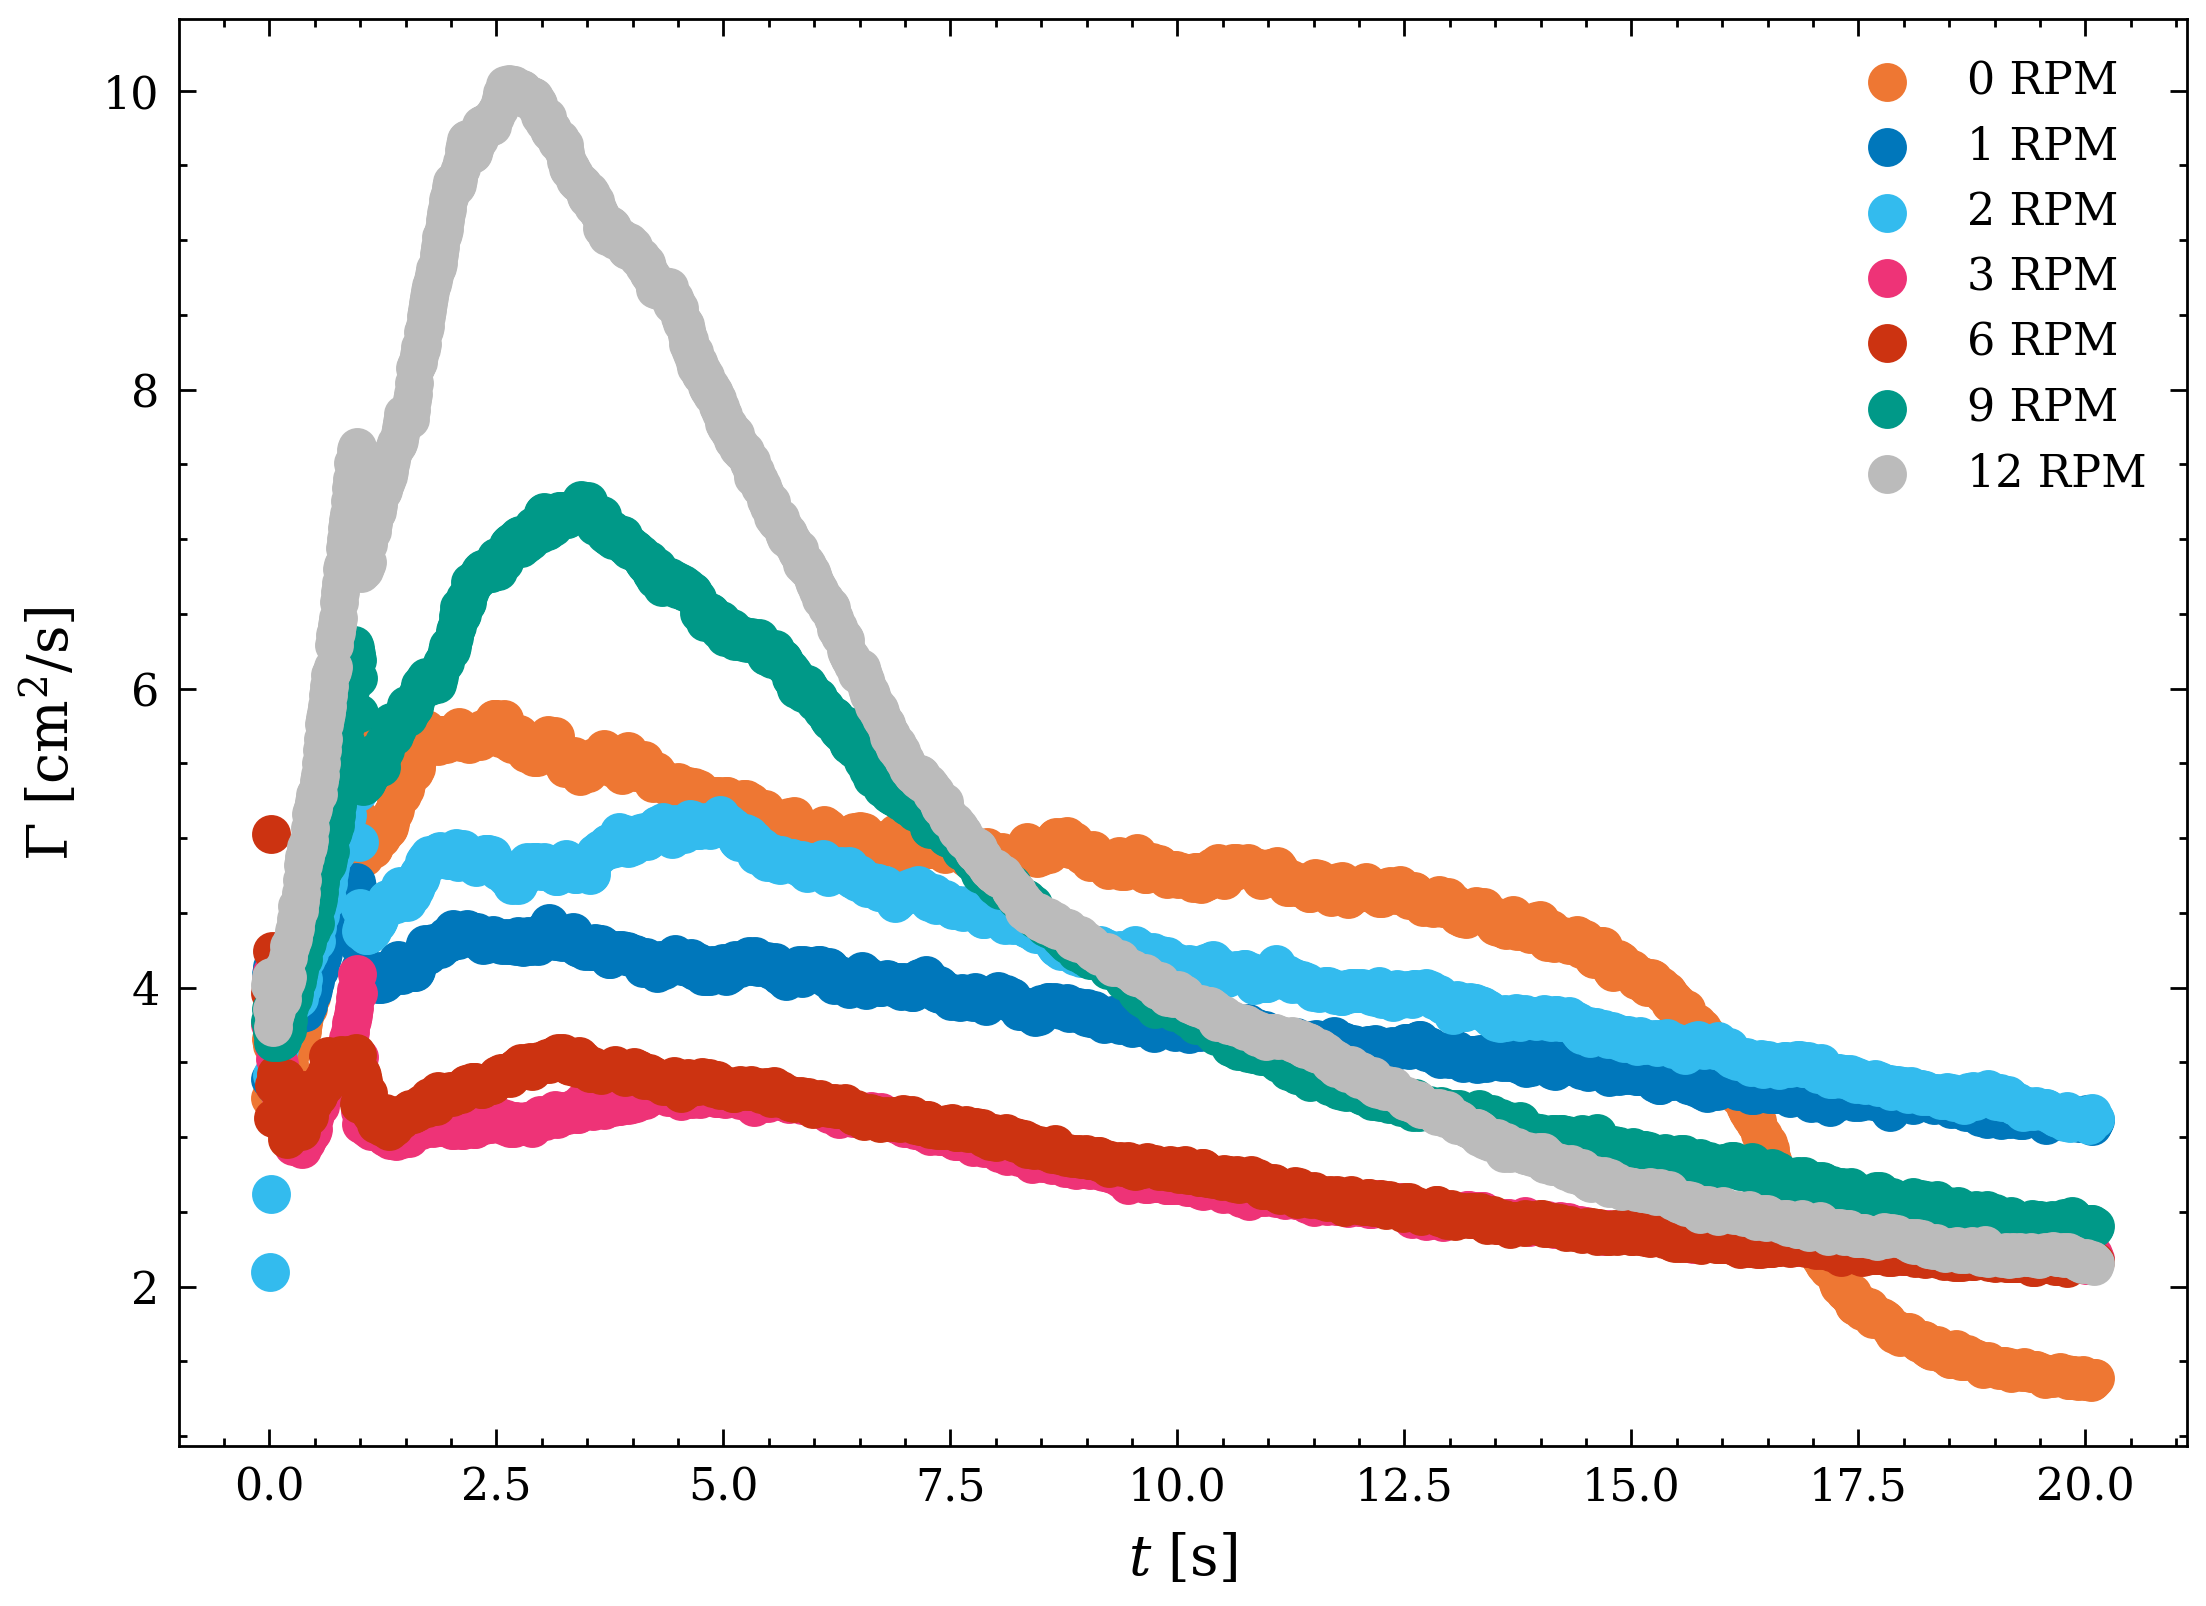

In [51]:
start_frame = 81
end_frame = 1891

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))

for i in range(7):
    ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[i, start_frame:end_frame], label='{} RPM'.format(rpms[i]))
    # ax.plot(Circulation[i, start_frame:end_frame], label='{} RPM'.format(rpms[i]))
# ax.plot(sumVorticity5050[:], label='{} RPM'.format(rpms[i]))
# ax.plot(Circulation[:], label='{} RPM'.format(rpms[i]))
ax.set_xlabel(r'$t$ [s]')
ax.set_ylabel(r'$\Gamma$ [cm$^2$/s]')
ax.legend(fontsize=8)
plt.show()

Different Injection lengths:

In [58]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
h5file = h5py.File('E:/H5/LengthTest.h5', 'r')

# lens = [50, 100]
lens = [25, 50, 75, 100, 125, 150, 175, 200, 225, 240]
Circulation = np.zeros([len(lens), u.shape[0]])


for i in range(len(lens)):
    print(lens[i])
    vels = h5file['Narrow']['U100']['L{}'.format(lens[i])]['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    # Circulation = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])

Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

25
50
75
100
125
150
175
200
225
240


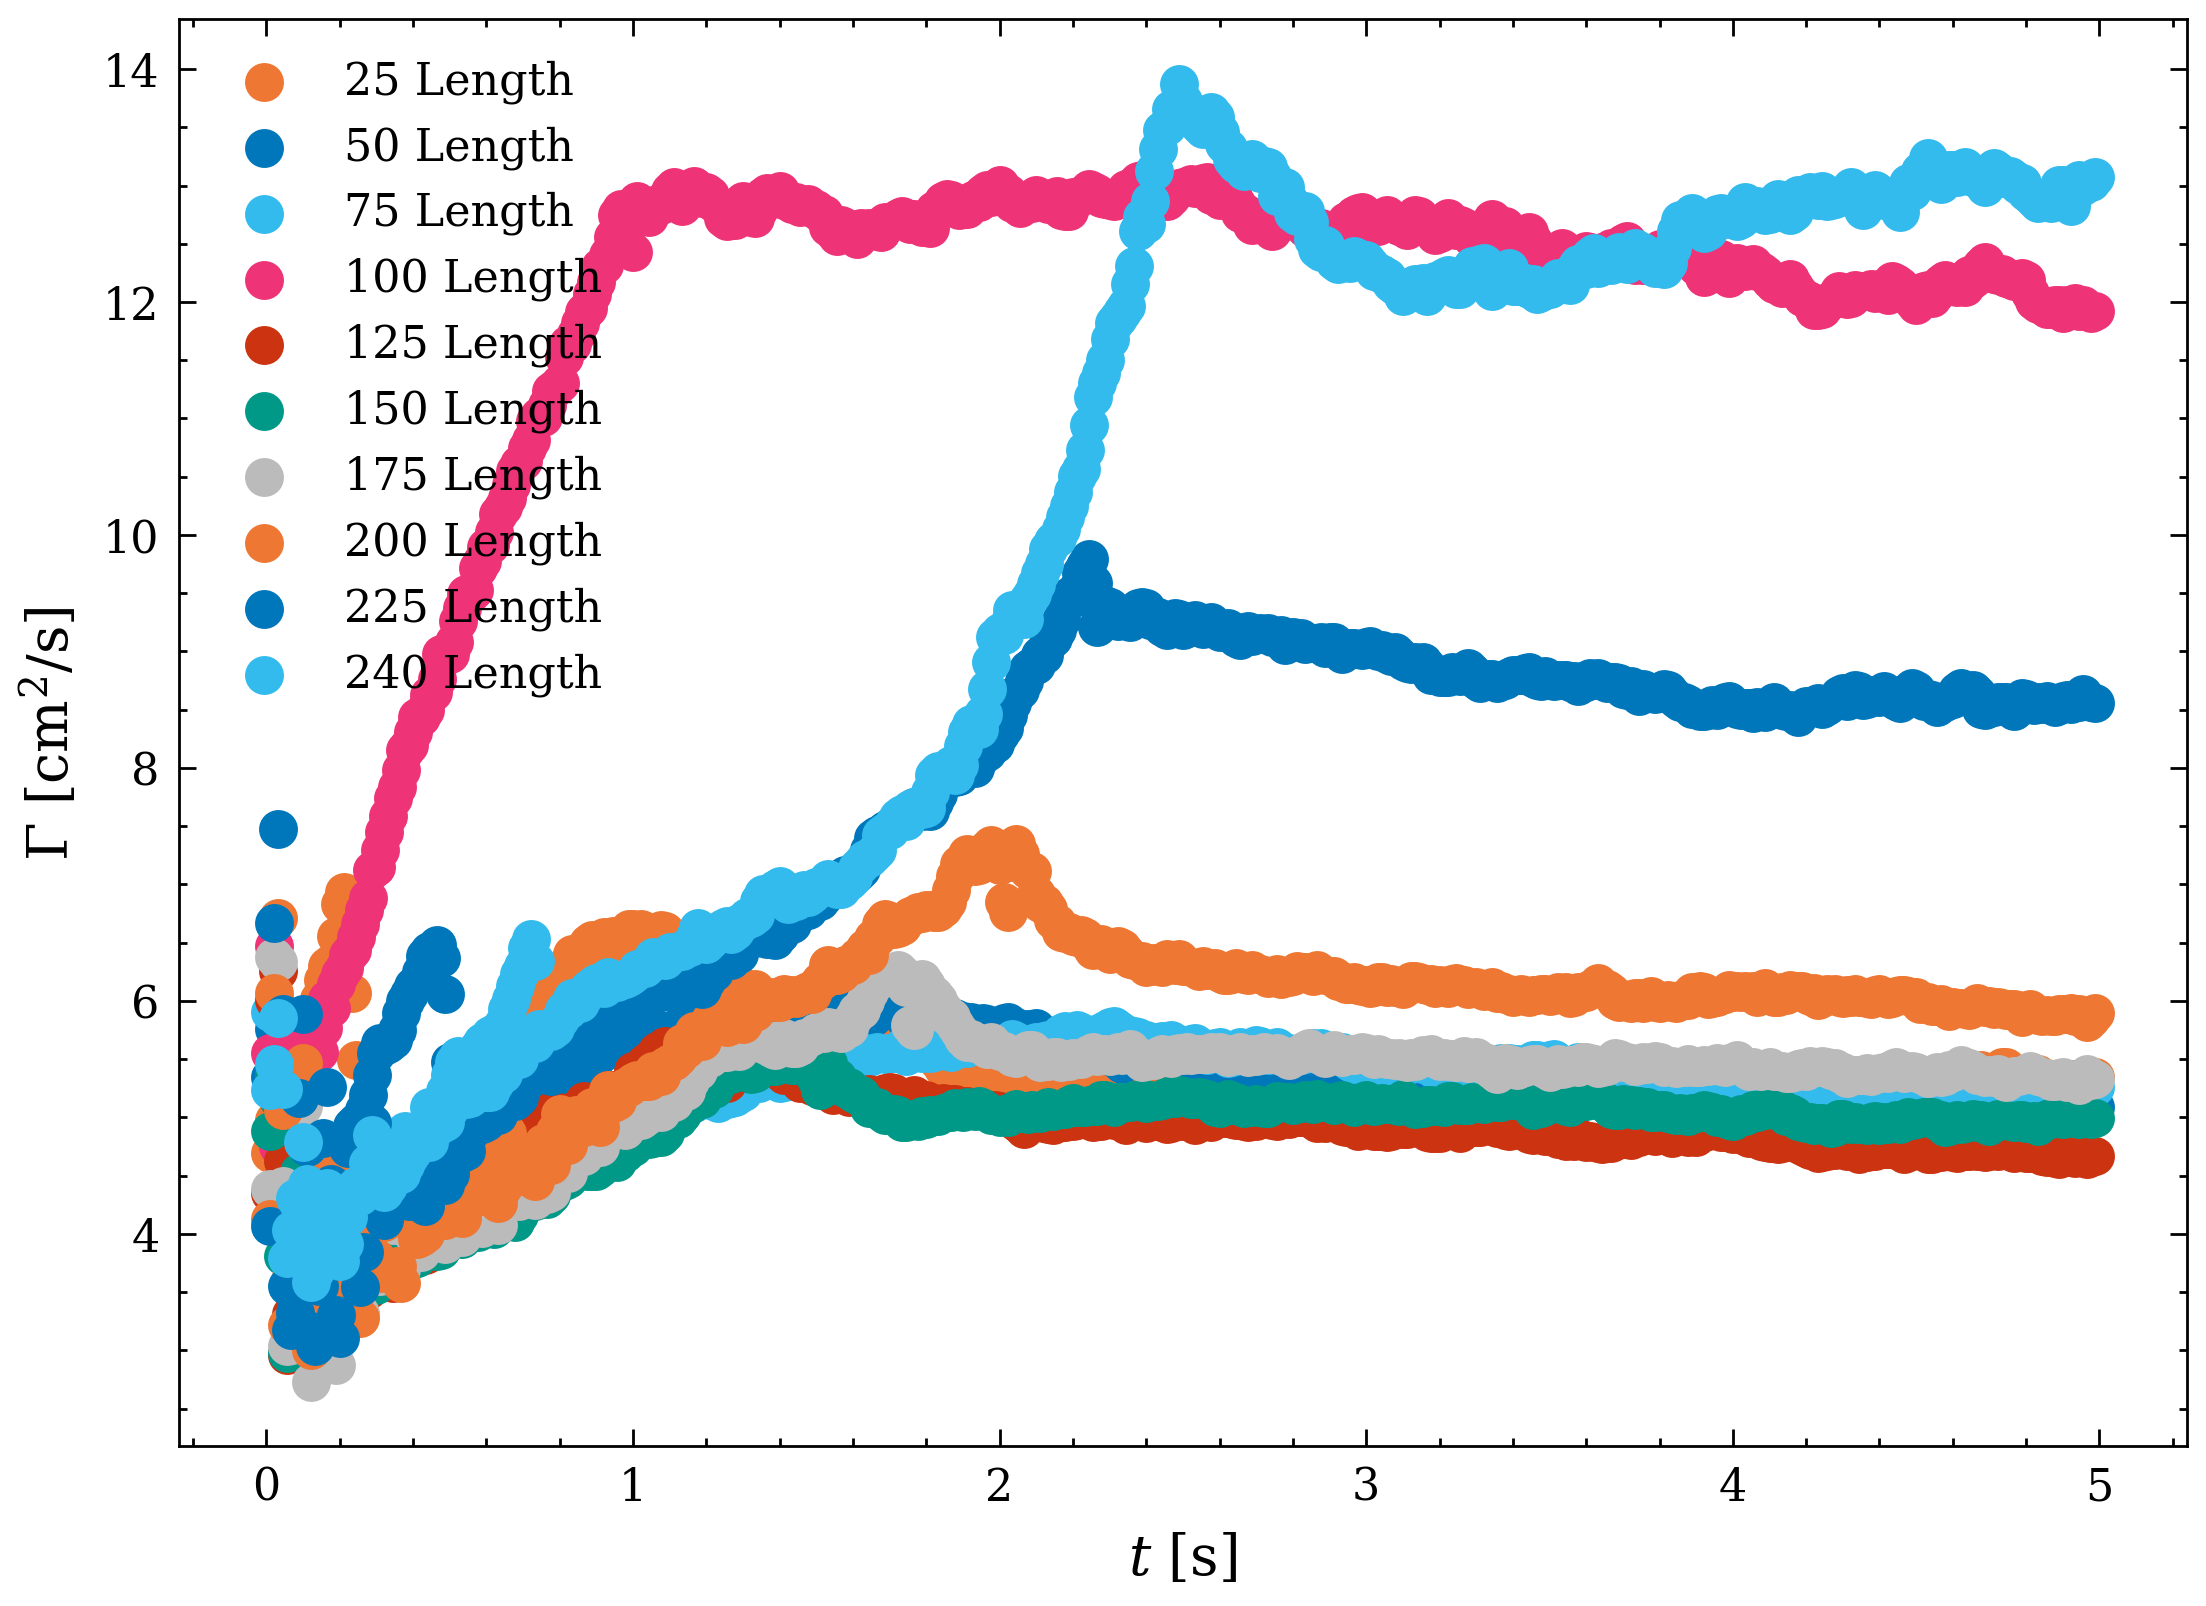

In [ ]:
start_frame = 81
end_frame = 530

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))

for i in range(len(lens)):
    ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[i, start_frame:end_frame], label='{} Length'.format(lens[i]))
    # ax.plot(Circulation[i, start_frame:end_frame], label='{} RPM'.format(rpms[i]))
# ax.plot(sumVorticity5050[:], label='{} RPM'.format(rpms[i]))
# ax.plot(Circulation[:], label='{} RPM'.format(rpms[i]))
ax.set_xlabel(r'$t$ [s]')
ax.set_ylabel(r'$\Gamma$ [cm$^2$/s]')
ax.legend(fontsize=8)
plt.show()